In [1]:
!pip install scikit-learn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

In [2]:
df = pd.read_csv("HealthConnect_cleaned_set.csv")

Feature Engineering & EDA

In [3]:
#Feature Engineering (Waiting time category) 1
df["booking_days_category"] = pd.cut(
    df["booking_lead_days"],
    bins=[-1, 3, 7, 14, float("inf")],
    labels=["Short", "Medium", "Long", "Very Long"]
)
df["booking_days_category"] = df["booking_days_category"]

pd.crosstab(
    df["booking_days_category"],
    df["appointment_outcome"],
    normalize="index"
) * 100

appointment_outcome,Attended,No-Show
booking_days_category,,
Short,73.400673,26.599327
Medium,67.752443,32.247557
Long,64.808362,35.191638
Very Long,42.596235,57.403765


In [4]:
#Encode
df["booking_days_category"] = df["booking_days_category"]
encoder = OrdinalEncoder(
    categories=[
        ["Short", "Medium", "Long", "Very Long"]
    ]
)

df[["booking_days_category"]] = encoder.fit_transform(
    df[["booking_days_category"]]
)

The new feature shows that people who wait very long have more no shows as opposed to the poepl who have short day.

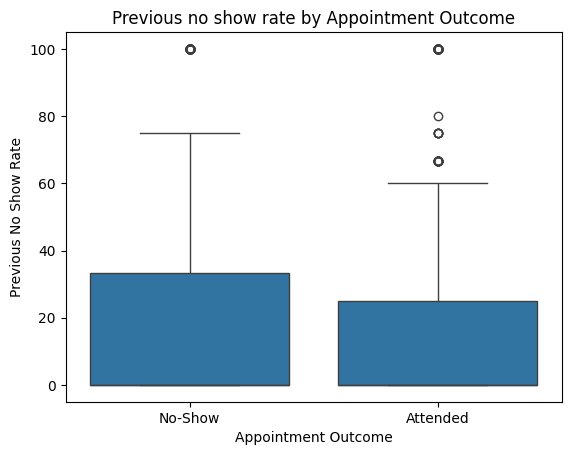

In [5]:
#Previous No Show Rate Feature 2
df["Previous_no_show_rate"] = (
    df["previous_no_shows"] /
    df["previous_appointments"].replace(0, np.nan)
)
df["Previous_no_show_rate"] = df["Previous_no_show_rate"] * 100

df = df

sns.boxplot(
    data=df,
    x="appointment_outcome",
    y="Previous_no_show_rate",
)

plt.title("Previous no show rate by Appointment Outcome")
plt.xlabel("Appointment Outcome")
plt.ylabel("Previous No Show Rate")
plt.show()



In [6]:
df["Previous_no_show_rate"] = df["Previous_no_show_rate"]

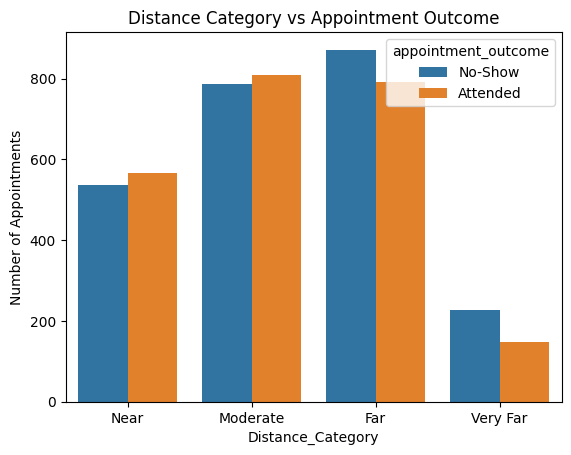

In [7]:
# Distance Category Feature 3
df["Distance_Category"] = pd.cut(
    df["distance_to_clinic_km"],
    bins=[-1, 5, 10, 20, float("inf")],
    labels=["Near", "Moderate", "Far", "Very Far"]
)


pd.crosstab(
    df["Distance_Category"],
    df["appointment_outcome"],
    normalize="index"
) * 100


sns.countplot(
    data=df,
    x="Distance_Category",
    hue="appointment_outcome"
)


plt.title("Distance Category vs Appointment Outcome")
plt.xlabel("Distance_Category")
plt.ylabel("Number of Appointments")
plt.show()

#Encode
df["Distance_Category"] = df["Distance_Category"]
encoder = OrdinalEncoder(
    categories=[
        ["Near", "Moderate", "Far", "Very Far"]
    ]
)

df[["Distance_Category"]] = encoder.fit_transform(
    df[["Distance_Category"]]
)


In [8]:
df["Distance_Category"] = df["Distance_Category"]

The further the distance category is the more no shows the data shows

In [9]:
#Reminder Feature 4
df["reminder_received"] = df["reminder_sent"].map({
    "Yes": 1,
    "No": 0
})

pd.crosstab(
    df["reminder_received"],
    df["appointment_outcome"],
    normalize=True
) * 100



appointment_outcome,Attended,No-Show
reminder_received,,
0,12.307368,14.819506
1,36.542115,36.331011


In [10]:
#Encoding Appointment_outcome
df["appointment_binary_outcome"] = df["appointment_outcome"].map({
    "Attended": 1,
    "No-Show": 0
    })


In [11]:
#Encoding Appointment_outcome
df["gender"] = df["gender"].map({
    "Male": 1,
    "Female": 0
    })

In [12]:
df["reminder_received"] = df["reminder_received"]
df.head(5)


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,...,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,booking_days_category,Previous_no_show_rate,Distance_Category,reminder_received,appointment_binary_outcome
0,HC-00001,P-1613,0.0,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,...,Yes,WhatsApp,19.3,29.0,No-Show,2.0,0.000000,2.0,1,0
1,HC-00002,P-0813,1.0,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,...,Yes,SMS,14.3,42.0,Attended,0.0,0.000000,2.0,1,1
2,HC-00003,P-1366,0.0,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,...,Yes,SMS,11.4,11.0,No-Show,3.0,20.000000,2.0,1,0
3,HC-00004,P-1031,1.0,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,...,Yes,SMS,7.4,35.0,Attended,3.0,33.333333,1.0,1,1
4,HC-00005,P-1458,0.0,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,...,Yes,Email,5.6,27.0,No-Show,3.0,33.333333,1.0,1,0


In [13]:
#Onehot Coding1
encoder = OneHotEncoder(
    drop="first",
    sparse_output=False
)

encoded = encoder.fit_transform(
    df[["appointment_type"]]
)

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["appointment_type"]),
    index=df.index

)
encoded_df.head()


,appointment_type_Follow-up,appointment_type_General Consultation,appointment_type_Specialist Consultation
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,0.0,1.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


In [14]:
#Onehot Coding2
encoder = OneHotEncoder(
    drop="first",
    sparse_output=False
)

encoded = encoder.fit_transform(
    df[["appointment_day"]]
)

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["appointment_day"]),
    index=df.index

)

In [15]:
#Onehot Coding1
encoder = OneHotEncoder(
    drop="first",
    sparse_output=False
)

encoded = encoder.fit_transform(
    df[["reminder_channel"]]
)

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["reminder_channel"]),
    index=df.index

)

In [16]:
df.to_csv("HealthConnect_ML_DataSet", index=True)

Dropping Irrelevant Columns
- Dropping patient ID and appointment ID
Then Saving final ML Data Set

In [17]:
df2 = pd.read_csv("HealthConnect_ML_DataSet")
df2.drop(columns=["appointment_id", "patient_id", "appointment_outcome"], inplace=True)
df2.to_csv("HealthConnect_ML_DataSet_Final", index=False)
df2.head(5)

,Unnamed: 0,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,...,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,booking_days_category,Previous_no_show_rate,Distance_Category,reminder_received,appointment_binary_outcome
0,0,0.0,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,...,0,Yes,WhatsApp,19.3,29.0,2.0,0.000000,2.0,1,0
1,1,1.0,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,...,0,Yes,SMS,14.3,42.0,0.0,0.000000,2.0,1,1
2,2,0.0,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,...,1,Yes,SMS,11.4,11.0,3.0,20.000000,2.0,1,0
3,3,1.0,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,...,1,Yes,SMS,7.4,35.0,3.0,33.333333,1.0,1,1
4,4,0.0,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,...,1,Yes,Email,5.6,27.0,3.0,33.333333,1.0,1,0


Modelling Clasification

In [18]:
# Seperating Features and Target
X = df2[["booking_lead_days", "age", "previous_no_shows", "distance_to_clinic_km", "waiting_time_minutes", "booking_days_category", "Distance_Category", "reminder_received"]]
y = df2["appointment_binary_outcome"]

y.value_counts()


appointment_binary_outcome
0    2423
1    2314
Name: count, dtype: int64

Spliting for Training And Testing

In [19]:
#Using 80/20 split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Baseline Model

In [20]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

Predictions
- Actual vs Predicted

In [21]:
y_pred = model.predict(X_test)
print(y_pred[:10])


#Comparing Actual vs Predicted
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

[0 1 1 0 0 1 1 0 0 1]


,Actual,Predicted
3165,0,0
2398,0,1
3424,1,1
1327,1,0
1942,1,0
3657,0,1
880,1,1
4505,1,0
2293,1,0
4225,0,1


Evaluating Model

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, classification_report, confusion_matrix
L_accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print(f" Accuracy: {L_accuracy} \n Precision: {precision}   \n  Recall: {recall} \n  f1: {f1}")



logistics_model = LogisticRegression(
    max_iter=100,
    random_state=42
)

lr_scores = cross_val_score(
    logistics_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)


print("Logistic Regression")
print("1st accuracy", lr_scores[0])
print("1st accuracy", lr_scores[1])
print("1st accuracy", lr_scores[2])
print("1st accuracy", lr_scores[3])
print("1st accuracy", lr_scores[4])

print("\n Mean Accuracy", lr_scores.mean())
print("\n Std Accuracy", lr_scores.std())


 Accuracy: 0.6054852320675106 
 Precision: 0.600451467268623   
  Recall: 0.5745140388768899 
  f1: 0.58719646799117


c:\Users\Koke\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Koke\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-

Logistic Regression
1st accuracy 0.6487341772151899
1st accuracy 0.6265822784810127
1st accuracy 0.6219640971488912
1st accuracy 0.6314677930306231
1st accuracy 0.6462513199577613

 Mean Accuracy 0.6349999331666958

 Std Accuracy 0.010662918074683954


Week 6 
- Recommendations
- Relooking at variables and finding suitable ways in increasing the accuracy of the model

Model Comparisons & Validation
- Random & Gradient Boostering Classifiers
- Decision Tree Classifier
- K Neighbors Classifier

In [36]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


random_forest = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42
)

random_forest.fit(X_train, y_train)
rf_predictions = random_forest.predict(X_test)
rf_accuracy = accuracy_score(y_test,rf_predictions)


print("Random Forest Accuracy:".format(rf_accuracy * 100))


# Validation
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_scores = cross_val_score(
    random_forest,
    X,
    y,
    cv=5,
    scoring="accuracy"
)


print("Random Forest")
print("\n Mean Accuracy", rf_scores.mean())
print("Std Accuracy", rf_scores.std())



gradient_boosting = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    random_state=42
)



gradient_boosting.fit(X_train, y_train)
gb_predictions = gradient_boosting.predict(X_test)

gb_accuracy = accuracy_score(y_test,gb_predictions)
print("GB Accuracy".format(gb_accuracy*100))



print((rf_accuracy*100))
print((gb_accuracy*100))


#validation
gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_scores = cross_val_score(
    gradient_boosting,
    X,
    y,
    cv=5,
    scoring="accuracy"
)


print("Gradient Boosting")
print("Scores", gb_scores)
print("Mean Accuracy", gb_scores.mean())

Random Forest Accuracy:
Random Forest

 Mean Accuracy 0.6048093245826259
Std Accuracy 0.012962191901156652
GB Accuracy
59.38818565400844
61.18143459915611
Gradient Boosting
Scores [0.6350211  0.61919831 0.63357973 0.61668427 0.62302006]
Mean Accuracy 0.6255006928385887


Decision Tree Classifier

In [37]:
#Model 3
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, Y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy", dt_accuracy)

print("\n Classification Report")
print(classification_report(y_test, y_pred_dt))

# Validation
decision_tree = DecisionTreeClassifier(random_state=42)

dt_scores = cross_val_score(
    decision_tree,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Decision Tree")
print("Scores", dt_scores)
print("Mean Accuracy", dt_scores.mean())

Decision Tree Accuracy 0.5548523206751055

 Classification Report
              precision    recall  f1-score   support

           0       0.57      0.54      0.55       485
           1       0.54      0.57      0.56       463

    accuracy                           0.55       948
   macro avg       0.56      0.56      0.55       948
weighted avg       0.56      0.55      0.55       948

Decision Tree
Scores [0.55485232 0.52004219 0.51425554 0.56705385 0.51214361]
Mean Accuracy 0.5336695048543257


K-Nearest Neighbors

In [38]:
#Model 4
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, Y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("Knn Accuracy", dt_accuracy)

print("\n Classification Report")
print(classification_report(y_test, y_pred_knn))


knn = KNeighborsClassifier(n_neighbors=5)

knn_scores = cross_val_score(
    knn,
    X,
    y,
    cv=5,
    scoring="accuracy"
)


print("KNN")
print("Scores", knn_scores)
print("Mean Accuracy", knn_scores.mean())



Knn Accuracy 0.5548523206751055

 Classification Report
              precision    recall  f1-score   support

           0       0.59      0.60      0.59       485
           1       0.57      0.56      0.57       463

    accuracy                           0.58       948
   macro avg       0.58      0.58      0.58       948
weighted avg       0.58      0.58      0.58       948

KNN
Scores [0.56329114 0.55485232 0.56282999 0.58817318 0.56388596]
Mean Accuracy 0.5666065166927317


Selecting Final Model

In [39]:
# Training Logistics Model as it is the most Accurate
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
final_model = LogisticRegression(
    max_iter=100,
    random_state=42
)

final_model.fit(X_train, y_train)

accuracy = accuracy_score(y_test, y_pred)


print("Final Logistics Regression Model")
print("Test Accuracy", accuracy)

print("\n Classification Report")
print(classification_report(y_test, y_pred))

print("\n Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

Final Logistics Regression Model
Test Accuracy 0.6054852320675106

 Classification Report
              precision    recall  f1-score   support

           0       0.61      0.64      0.62       485
           1       0.60      0.57      0.59       463

    accuracy                           0.61       948
   macro avg       0.61      0.60      0.60       948
weighted avg       0.61      0.61      0.61       948


 Confusion Matrix
[[308 177]
 [197 266]]


c:\Users\Koke\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [40]:
#Saving Final Model
import joblib
joblib.dump(final_model, "health_connect_logistic_regression_model.pkl")
print("Final Model Saved")

Final Model Saved


In [41]:
candidate_model = final_model

y_pred = candidate_model.predict(X_test)
y_prob = candidate_model.predict_proba(X_test)[:, 1]


print("Accuracy", accuracy_score(y_test, y_pred))

print("Precision", precision_score(y_test, y_pred))

print("Recall", recall_score(y_test, y_pred))

print("F1 Score", f1_score(y_test, y_pred))

print("ROC-AUC", roc_auc_score(y_test, y_prob))

print(classification_report(y_test, y_pred))

Accuracy 0.6054852320675106
Precision 0.600451467268623
Recall 0.5745140388768899
F1 Score 0.58719646799117
ROC-AUC 0.6538977088018526
              precision    recall  f1-score   support

           0       0.61      0.64      0.62       485
           1       0.60      0.57      0.59       463

    accuracy                           0.61       948
   macro avg       0.61      0.60      0.60       948
weighted avg       0.61      0.61      0.61       948



In [45]:
import pandas as pd
results = X_test.copy()

results["Actual"] = y_test
results["Predicted"] = y_pred
results["Probability"] = y_prob

#False Positives
false_positives = results[
    (results["Actual"] ==0) &
    (results["Predicted"] ==1)
]


#False Negatives
false_negatives = results[
    (results["Actual"] ==1) &
    (results["Predicted"] ==0)
]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))


print(false_positives.describe())
print(false_negatives.describe())

False Positives: 177
False Negatives: 197
       booking_lead_days         age  previous_no_shows  \
count         177.000000  177.000000         177.000000   
mean           18.881356   52.954802           0.299435   
std            10.444254   18.138614           0.538991   
min             0.000000   18.000000           0.000000   
25%            11.000000   41.000000           0.000000   
50%            18.000000   54.000000           0.000000   
75%            26.000000   69.000000           1.000000   
max            41.000000   80.000000           2.000000   

       distance_to_clinic_km  waiting_time_minutes  booking_days_category  \
count             177.000000            177.000000             177.000000   
mean                9.230617             23.811124               2.412429   
std                 6.340351             10.538294               0.907333   
min                 0.500000              2.000000               0.000000   
25%                 4.800000             

Error Investigating

In [53]:
fn_by_booking = (
    false_negatives
    .groupby("booking_days_category")
    .size()
    .reset_index(name="Count")
)

print(fn_by_booking)


error_analysis = results.groupby("booking_days_category").apply(
    lambda group: pd.Series({
        "Total": len(group),
        "Errors": (group["Actual"] != group["Predicted"]).sum(),
        "Error_Rate": (group["Actual"] != group["Predicted"]).mean()
    }),
    include_groups=False
)

print(error_analysis)

   booking_days_category  Count
0                    0.0      2
1                    1.0      2
2                    2.0      1
3                    3.0    192
                       Total  Errors  Error_Rate
booking_days_category                           
0.0                     60.0    13.0    0.216667
1.0                     64.0    20.0    0.312500
2.0                     99.0    36.0    0.363636
3.0                    725.0   305.0    0.420690


#features = [
   #"booking_lead_days",
    #"age",
    #"previous_no_shows",
    #"distance_to_clinic_km,
    #"waiting_time",
    #"booking_days_category",
    #"distance_category",
    #"reminder_recived"]

segment_results = []

for segment, group in reults.groupby("reminder_recived"):
   
   segment_results.append({
    "Reminder Received": segment,
    "Total": len(group),
    "Accuracy": accuracy_score(
        group["Actual"],
        group[""Predicted]
    ),

    "Recall": recall_score(
        group["Actual"],
        group["Predicted"],
        zero_division=0
    )
   })

   segment_df = pd.DataFrame(segment_results)
   print(segment_df)


In [54]:
train_pred = candidate_model.predict(X_train)

test_pred = candidate_model.predict(X_test)

print("Training Accuracy", accuracy_score(y_train, train_pred))

print("Test Accuracy", accuracy_score(y_test, test_pred))

print("Training F1", f1_score(y_train, train_pred))

print("Test F1", f1_score(y_test, test_pred))

Training Accuracy 0.6421219319081551
Test Accuracy 0.6054852320675106
Training F1 0.6291028446389497
Test F1 0.58719646799117


In [77]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    return{
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0),
        "ROC - AUC": roc_auc_score(y_test, probabilities)

    }

    baseline_results = evaluate_model(
        baseline_model,
        X_test,
        y_test
    )

    candidate_results = evaluate_model(
        candidate_model,
        X_test,
        y_test
    )

    comparison = pd.DataFrame({
        "Week 5 Baseline": baseline_results,
        "Week 6 Candidate": candidate_results
    })

    print(comparison)

In [78]:
#Review feature relevance
print(X_train.describe)

print(X_train["booking_days_category"].value_counts())
print(X_train["Distance_Category"].value_counts())
print(X_train["reminder_received"].value_counts())


<bound method NDFrame.describe of       booking_lead_days  age  previous_no_shows  distance_to_clinic_km  \
4262                 24   71                  0                   10.4   
1232                 29   78                  1                    5.7   
4660                 22   25                  0                   10.1   
3026                 31   23                  0                    3.3   
3384                 55   46                  0                    7.4   
...                 ...  ...                ...                    ...   
3086                 44   60                  0                   11.7   
486                  37   43                  0                   11.1   
943                  28   56                  0                   11.8   
2291                 14   22                  1                   34.4   
1714                 31   58                  0                    6.3   

      waiting_time_minutes  booking_days_category  Distance_Category  \
4262 

In [73]:
#Retest
final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

final_probabilities = final_model.predict_proba(X_test)[:, 1]


final_results = evaluate_model(
    final_model,
    X_test,
    y_test
)

print(final_results)

{'Accuracy': 0.6054852320675106, 'Precision': 0.600451467268623, 'Recall': 0.5745140388768899, 'F1 Score': 0.58719646799117, 'ROC - AUC': 0.6538977088018526}


c:\Users\Koke\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [82]:
final_results = evaluate_model(
    final_model,
    X_test,
    y_test
)

candidate_results = evaluate_model(
    candidate_model,
    X_test,
    y_test
)


final_comparison = pd.DataFrame({
    "Candidate": candidate_results,
    "Refined": final_results
})

print(final_comparison)



           Candidate   Refined
Accuracy    0.605485  0.605485
Precision   0.600451  0.600451
Recall      0.574514  0.574514
F1 Score    0.587196  0.587196
ROC - AUC   0.653898  0.653898
